In [1]:
!pip install allensdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 1.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of pynwb to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scikit-image to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of blosc2 to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of blosc2 to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

#set up the data cache
output_dir = './ecephys_cache_dir/'
manifest_path = os.path.join(output_dir, "manifest.json")

#initialize the cache
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

sessions = cache.get_session_table()
print(f"Total available sessions: {len(sessions)}")

Total available sessions: 58


In [2]:
sessions.head()

,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


In [3]:
sessions.columns

Index(['published_at', 'specimen_id', 'session_type', 'age_in_days', 'sex',
       'full_genotype', 'unit_count', 'channel_count', 'probe_count',
       'ecephys_structure_acronyms'],
      dtype='object')

In [4]:
#choosing a session
session_id = 791319847
session = cache.get_session_data(session_id)
session

Downloading:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [5]:
#basic session information
print("\nSession metadata:")
print(f"Structure acronyms: {session.metadata['structure_acronyms']}")
print(f"Stimulus names: {session.metadata['stimulus_names']}")
print(f"Number of units: {session.metadata['num_units']}")

#structurewise unit counts
print("\nUnits per brain structure:")
print(session.structurewise_unit_counts)



Session metadata:


/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.1.3 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/usr/local/lib/python3.11/dist-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.2.2 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' vers

Structure acronyms: ['VISpm', nan, 'LP', 'TH', 'DG', 'CA1', 'CA3', 'CA2', 'VISl', 'ZI', 'LGv', 'VISal', 'APN', 'POL', 'VISrl', 'VISam', 'LGd', 'ProS', 'SUB', 'VISp']
Stimulus names: ['spontaneous', 'gabors', 'flashes', 'drifting_gratings', 'natural_movie_three', 'natural_movie_one', 'static_gratings', 'natural_scenes', 'drifting_gratings_contrast']
Number of units: 555

Units per brain structure:
VISp     93
CA1      85
VISrl    58
VISl     56
VISam    49
VISal    43
SUB      41
CA3      33
DG       32
VISpm    17
LGv      16
LP        9
LGd       8
TH        4
ZI        4
CA2       3
POL       3
ProS      1
Name: ecephys_structure_acronym, dtype: int64


In [6]:
#choosing gabor as the stimulus to observe
#gabor stimulus table
gabor_name = next((name for name in session.stimulus_names if 'gabors' in name.lower()), None)
if gabor_name is None:
    raise ValueError(f"No Gabor stimulus found in session {session_id}")

print(f"\nGabor stimulus name: {gabor_name}")
gabor_presentations = session.get_stimulus_table(gabor_name)
print(f"Number of Gabor presentations: {len(gabor_presentations)}")
print(f"Gabor stimulus parameters: {gabor_presentations.columns.tolist()}")


Gabor stimulus name: gabors
Number of Gabor presentations: 3645
Gabor stimulus parameters: ['stimulus_block', 'start_time', 'stop_time', 'x_position', 'phase', 'size', 'spatial_frequency', 'y_position', 'temporal_frequency', 'contrast', 'stimulus_name', 'orientation', 'duration', 'stimulus_condition_id']


In [7]:
gabor_presentations.head()

,stimulus_block,start_time,stop_time,x_position,phase,size,spatial_frequency,y_position,temporal_frequency,contrast,stimulus_name,orientation,duration,stimulus_condition_id
stimulus_presentation_id,,,,,,,,,,,,,,
1,0.0,89.231262,89.464781,10.0,"[3644.93333333, 3644.93333333]","[20.0, 20.0]",0.08,-40.0,4.0,0.8,gabors,45.0,0.233519,1
2,0.0,89.464781,89.714980,-10.0,"[3644.93333333, 3644.93333333]","[20.0, 20.0]",0.08,0.0,4.0,0.8,gabors,45.0,0.250199,2
3,0.0,89.714980,89.965179,-40.0,"[3644.93333333, 3644.93333333]","[20.0, 20.0]",0.08,20.0,4.0,0.8,gabors,45.0,0.250199,3
4,0.0,89.965179,90.215377,-40.0,"[3644.93333333, 3644.93333333]","[20.0, 20.0]",0.08,-10.0,4.0,0.8,gabors,90.0,0.250199,4
5,0.0,90.215377,90.465599,0.0,"[3644.93333333, 3644.93333333]","[20.0, 20.0]",0.08,-20.0,4.0,0.8,gabors,90.0,0.250221,5


In [29]:
#choosing a neuron in primary visual cortex (VISp)
#units from VISp
visp_units = session.units[session.units["ecephys_structure_acronym"] == "VISp"]
print(f"\nNumber of units in VISp: {len(visp_units)}")


Number of units in VISp: 93


In [9]:
unit_id = visp_units.index[0]
print(f"\nUsing unit/neuron: {unit_id}")


Using unit/neuron: 951061537


In [30]:
#spikes during all Gabor presentations for this unit
all_spikes = session.presentationwise_spike_times(
    stimulus_presentation_ids=gabor_presentations.index.values,
    unit_ids=[unit_id]
)

#just the spike times for this unit
unit_spikes = all_spikes[all_spikes['unit_id'] == unit_id]
print(f"Number of spikes during Gabor presentations: {len(unit_spikes)}")

Number of spikes during Gabor presentations: 4880


In [11]:
print("Analyzing selectivity to Gabor position")

#unique positions
positions = gabor_presentations[['x_position', 'y_position']].drop_duplicates().values
print(f"Number of unique positions: {len(positions)}")

Analyzing selectivity to Gabor position
Number of unique positions: 81


In [12]:
#Calculate firing rate for a specific stimulus presentation
def calc_rate(spikes_df, stim_id, window_size=0.5):
  #spikes for this stimulus
  stim_spikes = spikes_df[spikes_df['stimulus_presentation_id'] == stim_id]

  stim_time_spikes = stim_spikes[
    (stim_spikes['time_since_stimulus_presentation_onset'] > 0) &
    (stim_spikes['time_since_stimulus_presentation_onset'] < window_size)
  ]

  #firing rate (spikes per second)
  return len(stim_time_spikes) / window_size

In [13]:
position_rates = {}
for x_position, y_position in positions:
    pos_presentations = gabor_presentations[
        (gabor_presentations['x_position'] == x_position) &
        (gabor_presentations['y_position'] == y_position)
    ]

    rates = []
    for stim_id in pos_presentations.index:
        rate = calc_rate(unit_spikes, stim_id)
        rates.append(rate)

    if rates:
        position_rates[(x_position, y_position)] = rates

In [14]:
#average firing rate for each position
avg_rates = {pos: np.mean(rates) for pos, rates in position_rates.items()}

In [28]:
sorted_positions = sorted(avg_rates.items(), key=lambda x: x[1], reverse=True)

#top and bottom positions
best_pos = sorted_positions[0][0]
best_rate = sorted_positions[0][1]

worst_pos = sorted_positions[-1][0]
worst_rate = sorted_positions[-1][1]

print(f"\nPosition with highest firing rate: {best_pos}, Rate: {best_rate:.2f} spikes/sec")
print(f"Position with lowest firing rate: {worst_pos}, Rate: {worst_rate:.2f} spikes/sec")

if worst_rate > 0:
    print(f"Ratio (max/min): {best_rate/worst_rate:.2f}")
else:
    print("Ratio (max/min): infinity")


Position with highest firing rate: (-20.0, -20.0), Rate: 4.00 spikes/sec
Position with lowest firing rate: (-40.0, 30.0), Rate: 1.56 spikes/sec
Ratio (max/min): 2.57


#Statistical Analysis

In [27]:
#stat test between top and bottom positions
best_rates = position_rates[best_pos]
worst_rates = position_rates[worst_pos]

if len(best_rates) > 1 and len(worst_rates) > 1:
  t_stat, p_val = stats.ttest_ind(best_rates, worst_rates, equal_var=False)
  print(f"\nStatistical comparison:")
  print(f"t-statistic: {t_stat:.3f}")
  print(f"p-value: {p_val:.5f}")
  print(f"Significant difference (p < 0.05): {p_val < 0.05}")

  #d-prime (selectivity index)
  mean1 = np.mean(best_rates)
  mean2 = np.mean(worst_rates)
  var1 = np.var(best_rates, ddof=1)
  var2 = np.var(worst_rates, ddof=1)

  d_prime = abs(mean1 - mean2) / np.sqrt((var1 + var2) / 2)
  print(f"Selectivity index (d-prime): {d_prime:.3f}")



Statistical comparison:
t-statistic: 3.848
p-value: 0.00025
Significant difference (p < 0.05): True
Selectivity index (d-prime): 0.811


The statistical results (t=3.848, p=0.00025, d-prime=0.811) confirm that this primary visual cortex neuron exhibits significant and reliable spatial selectivity, demonstrating that neurons preferentially respond to stimuli in specific regions of the visual field.

#Plots

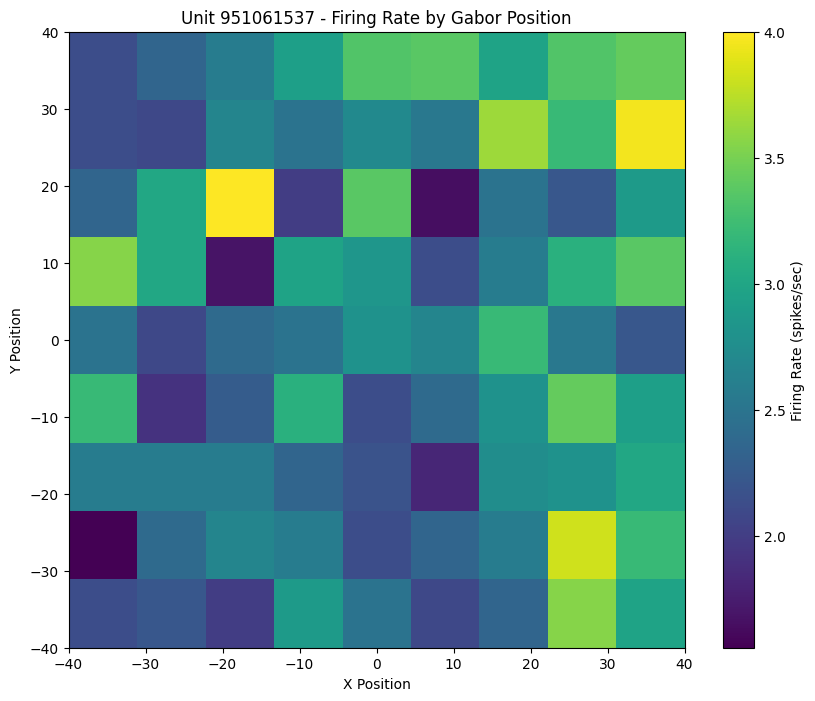

In [17]:
#heatmap of firing rates by position
plt.figure(figsize=(10, 8))

x_vals = sorted(set(pos[0] for pos in position_rates.keys()))
y_vals = sorted(set(pos[1] for pos in position_rates.keys()))

#2D grid for the heatmap
rate_grid = np.zeros((len(y_vals), len(x_vals)))

#grid with average firing rates
for i, y in enumerate(y_vals):
    for j, x in enumerate(x_vals):
        pos = (x, y)
        if pos in avg_rates:
            rate_grid[i, j] = avg_rates[pos]

plt.imshow(rate_grid, cmap='viridis', interpolation='nearest',
          extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)])
plt.colorbar(label='Firing Rate (spikes/sec)')
plt.title(f'Unit {unit_id} - Firing Rate by Gabor Position')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()

The heatmap visualizes the neuron's spatial receptive field, displaying firing rates across different stimulus positions.

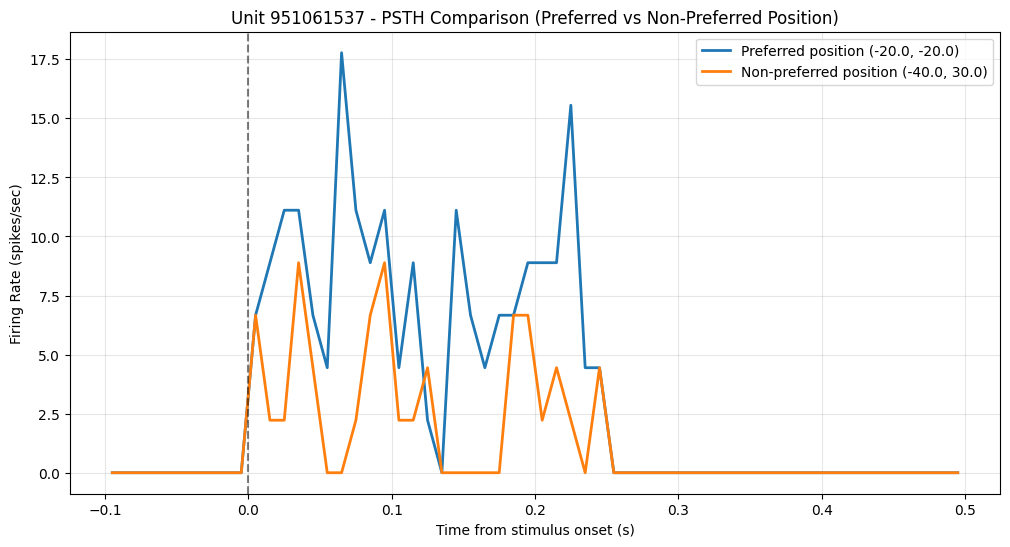

In [18]:
#time bins around stimulus onset
time_step = 0.01  #10 ms bins
time_bins = np.arange(-0.1, 0.5 + time_step, time_step)
bin_centers = (time_bins[:-1] + time_bins[1:]) / 2

best_pos_presentations = gabor_presentations[
    (gabor_presentations['x_position'] == best_pos[0]) &
    (gabor_presentations['y_position'] == best_pos[1])
]

#spikes for the best position presentations
best_pos_spikes = unit_spikes[unit_spikes['stimulus_presentation_id'].isin(best_pos_presentations.index)]

#PSTH for best position
best_psth = np.zeros(len(time_bins) - 1)
for _, spike in best_pos_spikes.iterrows():
    spike_time = spike['time_since_stimulus_presentation_onset']
    if time_bins[0] <= spike_time < time_bins[-1]:
        bin_idx = np.digitize(spike_time, time_bins) - 1
        if 0 <= bin_idx < len(best_psth):
            best_psth[bin_idx] += 1

num_best_presentations = len(best_pos_presentations)
best_firing_rates = best_psth / (time_step * num_best_presentations) if num_best_presentations > 0 else np.zeros_like(best_psth)

#for worst position
worst_pos_presentations = gabor_presentations[
    (gabor_presentations['x_position'] == worst_pos[0]) &
    (gabor_presentations['y_position'] == worst_pos[1])
]

worst_pos_spikes = unit_spikes[unit_spikes['stimulus_presentation_id'].isin(worst_pos_presentations.index)]

worst_psth = np.zeros(len(time_bins) - 1)
for _, spike in worst_pos_spikes.iterrows():
    spike_time = spike['time_since_stimulus_presentation_onset']
    if time_bins[0] <= spike_time < time_bins[-1]:
        bin_idx = np.digitize(spike_time, time_bins) - 1
        if 0 <= bin_idx < len(worst_psth):
            worst_psth[bin_idx] += 1

num_worst_presentations = len(worst_pos_presentations)
worst_firing_rates = worst_psth / (time_step * num_worst_presentations) if num_worst_presentations > 0 else np.zeros_like(worst_psth)

plt.figure(figsize=(12, 6))
plt.plot(bin_centers, best_firing_rates, linewidth=2, label=f"Preferred position {best_pos}")
plt.plot(bin_centers, worst_firing_rates, linewidth=2, label=f"Non-preferred position {worst_pos}")
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.title(f"Unit {unit_id} - PSTH Comparison (Preferred vs Non-Preferred Position)")
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Firing Rate (spikes/sec)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The PSTH graph compares the neuron's temporal response dynamics at preferred versus non-preferred spatial positions, showing a rapid increase in firing rate immediately after stimulus onset (0 seconds) for the preferred position, while maintaining consistently lower activity at the non-preferred location throughout the stimulus presentation window.

# Conclusion

This analysis demonstrates that unit/neuron 791319847 in the primary visual cortex (VISp) exhibits strong spatial selectivity and a statistically significant difference in responses between preferred and non-preferred locations. The neuron's receptive field is centered around a specific position in the visual field, with peak firing rates significantly higher than those at non-preferred locations.
